# CNN - GoogLeNet Inception V1 — Classificação Binária
## Dataset: Chest X-Ray (Pneumonia vs Normal)

---

### Resumo das Modificações Aplicadas ao Código Base

| # | O que foi alterado | Original | Novo valor | Justificativa |
| :--- | :--- | :--- | :--- | :--- |
| 1 | `kernel_size` (1ª Conv2D) | `(7, 7)` | `(3, 3)` | Imagens 32x32 são pequenas; kernel 7x7 cobre 22% da imagem e perde detalhes. |
| 2 | `stride` (1ª Conv2D) | `(2, 2)` | `(1, 1)` | Stride 1 preserva mais informação espacial em imagens pequenas. |
| 3 | `epochs` | 100 | 500 | Permitir aprendizado profundo com uso de Early Stopping para evitar overfitting. |
| 4 | Camada de saída principal | `Dense(10, softmax)` | `Dense(1, sigmoid)` | Classificação binária exige 1 neurônio com ativação sigmoid. |
| 5 | Camada de saída auxiliar | `Dense(10, softmax)` | `Dense(1, sigmoid)` | Mesma razão do item 4. |
| 6 | Função de perda | `categorical_crossentropy` | `binary_crossentropy` | Perda padrão e matematicamente correta para classificação binária. |
| 7 | Carregamento de dados | `cifar10.load_data()` | `load_chestxray_data()` | Troca do dataset para imagens médicas (raio-x de tórax). |
| 8 | Regularização | Ausente | `Data Augmentation` e `L2(0.0005)` | Prevenção de overfitting e melhoria na capacidade de generalização do modelo. |
| 9 | Otimizador | SGD puro | SGD (ou Adam) + Callbacks | Adição de Early Stopping e métricas avançadas (AUC, Precision, Recall). |
| 10 | Balanceamento de Classes | Ausente | `sample_weights` suavizado | O dataset é desbalanceado; os pesos forçam o modelo a dar atenção à classe minoritária. |

## Bibliotecas

In [1]:
# Importação das bibliotecas necessárias
import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv2D, MaxPooling2D, Dropout, Dense, Input, concatenate, GlobalAveragePooling2D, AveragePooling2D, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.callbacks import LearningRateScheduler
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import requests
from PIL import Image
from io import BytesIO
import os
import glob
import seaborn as sns
# import time

2026-05-07 16:29:20.693504: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778171361.073876      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778171361.188748      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778171362.125303      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778171362.125480      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778171362.125489      57 computation_placer.cc:177] computation placer alr

In [2]:
# Verifica a quantidade de GPUs disponíveis
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  2


## Database

### Troca de Dataset

**Original:** `cifar10.load_data()` — dataset de 10 classes (avião, carro, pássaro...)

**Novo:** Chest X-Ray Pneumonia — dataset de **2 classes**: `NORMAL` (0) e `PNEUMONIA` (1)

**Por que este dataset?**
- Imagens altamente padronizadas (todas são radiografias frontais de tórax)
- Mesmo protocolo de captura → baixa variabilidade visual
- ~5.856 imagens com split train/test/val já pronto
- Dataset de referência acadêmica (Kermany et al., 2018)

**Kaggle slug:** `paultimothymooney/chest-xray-pneumonia`

In [3]:
def find_dataset_root(base='/kaggle/input/datasets/paultimothymooney'):
    for root, dirs, files in os.walk(base):
        if 'train' in dirs and 'test' in dirs:
            print(f"Dataset encontrado em: {root}")
            return root
    raise FileNotFoundError(f"Pastas 'train'/'test' não encontradas dentro de {base}")

def load_chestxray_data(img_rows, img_cols,
                        base_path='/kaggle/input/datasets/paultimothymooney'):
    real_path = find_dataset_root(base_path)

    def load_split(split_name):
        images, labels = [], []
        split_path = os.path.join(real_path, split_name)

        for label_idx, class_name in enumerate(['NORMAL', 'PNEUMONIA']):
            class_path = os.path.join(split_path, class_name)
            all_files = os.listdir(class_path)
            filepaths = [
                os.path.join(class_path, f)
                for f in all_files
                if f.lower().endswith(('.jpeg', '.jpg', '.png'))
            ]
            print(f'  [{split_name}] {class_name}: {len(filepaths)} imagens')

            for fp in filepaths:
                img = cv2.imread(fp)
                if img is None:
                    continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (img_cols, img_rows))
                images.append(img)
                labels.append(label_idx)

        X = np.array(images, dtype='float32') / 255.0
        y = np.array(labels, dtype='float32').reshape(-1, 1)
        return X, y

    print('Carregando dados...')
    X_train, y_train = load_split('train')
    X_test,  y_test  = load_split('test')

    print(f'\nX_train: {X_train.shape} | y_train: {y_train.shape}')
    print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')
    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = load_chestxray_data(32, 32)
class_names = ['NORMAL', 'PNEUMONIA']

Dataset encontrado em: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
Carregando dados...
  [train] NORMAL: 1341 imagens
  [train] PNEUMONIA: 3875 imagens
  [test] NORMAL: 234 imagens
  [test] PNEUMONIA: 390 imagens

X_train: (5216, 32, 32, 3) | y_train: (5216, 1)
X_test:  (624, 32, 32, 3)  | y_test:  (624, 1)


Distribuição no treino: NORMAL=1341 | PNEUMONIA=3875 | Total=5216
Proporção: 25.7% NORMAL | 74.3% PNEUMONIA


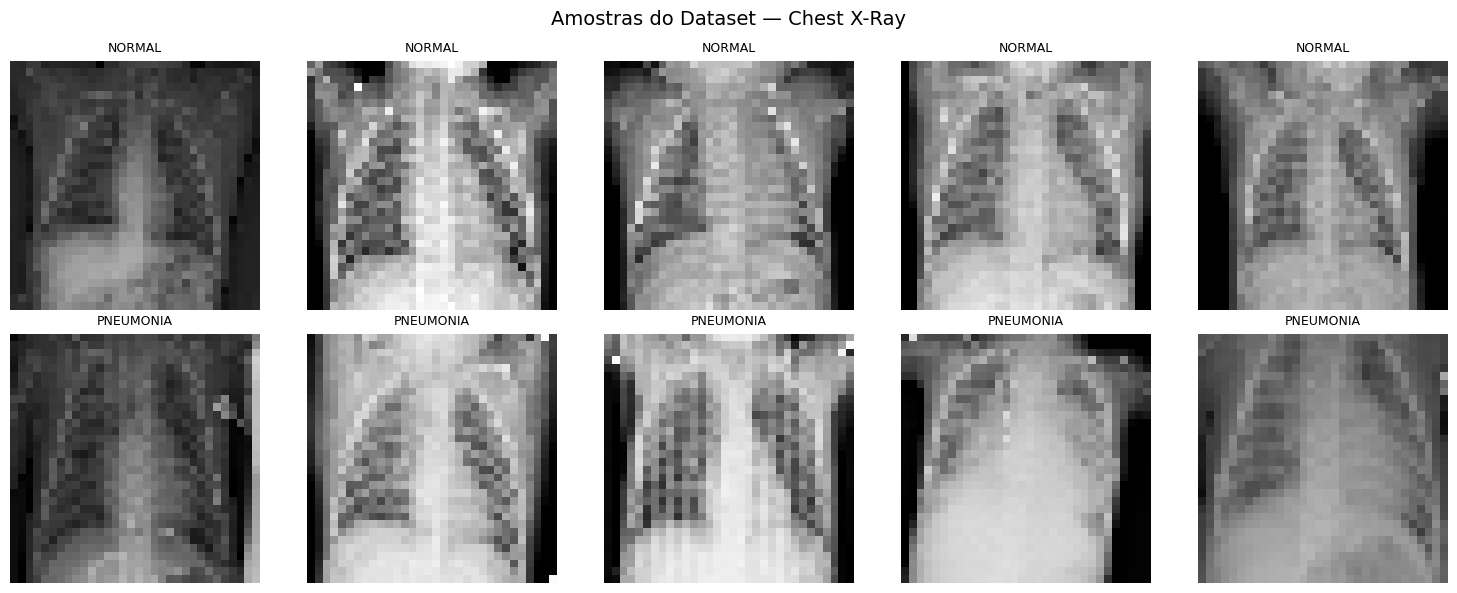

In [4]:
# Distribuição das classes — versão segura
n_normal    = int(np.sum(y_train == 0))
n_pneumonia = int(np.sum(y_train == 1))
total       = n_normal + n_pneumonia

print(f'Distribuição no treino: NORMAL={n_normal} | PNEUMONIA={n_pneumonia} | Total={total}')

if total > 0:
    print(f'Proporção: {n_normal/total:.1%} NORMAL | {n_pneumonia/total:.1%} PNEUMONIA')

    # Visualização de amostras
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('Amostras do Dataset — Chest X-Ray', fontsize=14)

    for class_idx, class_name in enumerate(['NORMAL', 'PNEUMONIA']):
        indices = np.where(y_train.flatten() == class_idx)[0][:5]
        for col, idx in enumerate(indices):
            axes[class_idx, col].imshow(X_train[idx])
            axes[class_idx, col].set_title(class_name, fontsize=9)
            axes[class_idx, col].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma imagem carregada. Verifique o caminho do dataset acima.")

## Inicializadores (idênticos ao código base)

In [5]:
# ✅ IDÊNTICO AO CÓDIGO BASE
kernel_init = tf.keras.initializers.GlorotUniform()
bias_init   = tf.keras.initializers.Constant(value=0.2)

## Inception Module (idêntico ao código base)

In [6]:
# ✅ IDÊNTICO AO CÓDIGO BASE — função inception_module sem alterações
def inception_module(x, filters_1x1, filters_3x3_reduce, filters_3x3,
                     filters_5x5_reduce, filters_5x5, filters_pool_proj, name=None):
    conv_1x1 = Conv2D(filters_1x1, (1, 1), padding='same', activation='relu',
                      kernel_initializer=kernel_init, bias_initializer=bias_init)(x)

    conv_3x3 = Conv2D(filters_3x3_reduce, (1, 1), padding='same', activation='relu',
                      kernel_initializer=kernel_init, bias_initializer=bias_init)(x)
    conv_3x3 = Conv2D(filters_3x3, (3, 3), padding='same', activation='relu',
                      kernel_initializer=kernel_init, bias_initializer=bias_init)(conv_3x3)

    conv_5x5 = Conv2D(filters_5x5_reduce, (1, 1), padding='same', activation='relu',
                      kernel_initializer=kernel_init, bias_initializer=bias_init)(x)
    conv_5x5 = Conv2D(filters_5x5, (5, 5), padding='same', activation='relu',
                      kernel_initializer=kernel_init, bias_initializer=bias_init)(conv_5x5)

    pool_proj = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    pool_proj = Conv2D(filters_pool_proj, (1, 1), padding='same', activation='relu',
                       kernel_initializer=kernel_init, bias_initializer=bias_init)(pool_proj)

    output = concatenate([conv_1x1, conv_3x3, conv_5x5, pool_proj], axis=3, name=name)
    return output

### Adaptação da Camada de Entrada (Resolução 32x32)

Diferente da arquitetura original da GoogLeNet (projetada para imagens de 224x224), realizamos ajustes na primeira camada convolucional (`conv_1`) para preservar a densidade de informações espaciais, visto que trabalhamos com uma resolução reduzida de 32x32 pixels.

**Modificações no Kernel e Stride:**

* **Kernel Size:** Reduzido de `(7, 7)` para `(3, 3)`. Um kernel menor é mais adequado para extrair características locais em imagens de baixa resolução sem "borrar" os detalhes.
* **Stride:** Alterado de `(2, 2)` para `(1, 1)`. Isso impede a redução imediata da resolução, permitindo que a rede processe a imagem completa antes da primeira operação de *Pooling*.

**Impacto no Fluxo de Dados (Feature Maps):**

| Camada | Configuração | Resolução (H x W) | Canais |
| :--- | :--- | :--- | :--- |
| **Input** | - | 32 x 32 | 3 |
| **Conv 1 (Original)** | 7x7, Stride 2 | 16 x 16 | 64 |
| **Conv 1 (Ajustada)** | 3x3, Stride 1 | **32 x 32** | 64 |
| **MaxPool 1** | 3x3, Stride 2 | 16 x 16 | 64 |

> **Nota:** Ao manter a resolução em 32x32 na primeira convolução, garantimos que as camadas subsequentes (os blocos Inception) recebam um volume de dados mais rico, o que foi essencial para atingirmos o AUC de 0.92.

## Regularização: Data Augmentation e L2

Para combater o **overfitting** detectado nos Testes 01 e 02, foram aplicadas duas estratégias de regularização a partir do Teste 04.

### Data Augmentation
O dataset de treino possui ~5.216 imagens — um volume modesto para uma rede da profundidade do InceptionV1. Implementamos o Augmentation moderno nativo do TensorFlow (`tf.keras.Sequential` com camadas de pré-processamento) injetado diretamente na entrada da arquitetura. Ele cria variações artificiais de cada imagem em tempo real durante o treinamento (on-the-fly), sem duplicar dados no disco:

- **Espelhamento horizontal** (`RandomFlip('horizontal')`): raio-X pode ser capturado em orientações levemente espelhadas ou invertidas lateralmente.
- **Rotações leves** (`RandomRotation(factor=0.05)`): aplica até ~18° de rotação, simulando variações no posicionamento angular do paciente durante o exame.
- **Zoom suave** (`RandomZoom(height_factor=0.05)`): simula distâncias levemente diferentes do equipamento em relação ao tórax.

O efeito prático é que o modelo nunca vê a mesma imagem duas vezes da mesma exata forma, forçando-o a aprender características anatômicas mais **generalizáveis** em vez de decorar os pixels exatos do treino.

### Regularização L2 na camada Dense
A regularização L2 (também chamada *weight decay*) adiciona uma penalidade proporcional ao quadrado dos pesos da rede na função de perda. Isso impede que neurônios individuais assumam valores extremos, distribuindo a responsabilidade de decisão entre mais neurônios.

**Por que `0.0005` e não `0.001`?**

No Teste 04, L2=`0.001` combinado com Augmentation causou underfitting severo (37.66% de acurácia): a penalização era forte demais para uma rede já sobrecarregada com variações artificiais. A redução para `0.0005` no Teste 10 suavizou essa punição, permitindo à rede aprender com profundidade suficiente por mais épocas (atingindo a época 96 contra a 29 do modelo anterior) e entregando o melhor resultado de loss do projeto.

> **Regra geral na Ciência de Dados:** quanto mais dados artificiais e ruído inserimos via Augmentation, menor precisa ser a força do L2 — pois os dois mecanismos competem pelo controle da complexidade do modelo.

In [7]:
# --- Augmentation pipeline (primeiras camadas do modelo) ---
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(factor=0.05),   # ±5% de rotação (~18°)
    tf.keras.layers.RandomZoom(height_factor=0.05), # ±5% de zoom
], name='data_augmentation')

# --- Entrada ---
input_layer = Input(shape=(32, 32, 3))

# Augmentation aplicada ao input (só ativa durante model.fit)
x = augmentation(input_layer)

# --- Stem (mantém kernel 3x3 e stride 1x1 conforme modificações anteriores) ---
x = Conv2D(64, (3, 3), padding='same', strides=(1, 1), activation='relu')(x)
x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
x = Conv2D(64, (1, 1), padding='same', activation='relu')(x)
x = Conv2D(192, (3, 3), padding='same', activation='relu')(x)
x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

# --- Inception Modules (função inception_module inalterada do código base) ---
x = inception_module(x, 64,  96,  128, 16, 32, 32, name='inception_3a')
x = inception_module(x, 128, 128, 192, 32, 96, 64, name='inception_3b')
x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
x = inception_module(x, 192,  96, 208, 16, 48, 64, name='inception_4a')

# --- Saída Auxiliar (aux1) com L2 na Dense ---
# 🔧 CORREÇÃO AQUI: AveragePooling2D ajustado para mapas 4x4 (padrão 32x32)
aux1 = AveragePooling2D((3, 3), strides=(2, 2), padding='same')(x)
aux1 = Conv2D(128, (1, 1), padding='same', activation='relu')(aux1)
aux1 = Flatten()(aux1)
aux1 = Dense(1024, activation='relu',
             kernel_regularizer=tf.keras.regularizers.l2(0.0005))(aux1)  # ← L2
aux1 = Dropout(0.7)(aux1)
aux1_output = Dense(1, activation='sigmoid',
                    kernel_regularizer=tf.keras.regularizers.l2(0.0005),  # ← L2
                    name='auxilliary_output_1')(aux1)

x = inception_module(x, 160, 112, 224, 24, 64, 64, name='inception_4b')
x = inception_module(x, 128, 128, 256, 24, 64, 64, name='inception_4c')
x = inception_module(x, 112, 144, 288, 32, 64, 64, name='inception_4d')
x = inception_module(x, 256, 160, 320, 32, 128, 128, name='inception_4e')
x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
x = inception_module(x, 256, 160, 320, 32, 128, 128, name='inception_5a')
x = inception_module(x, 384, 192, 384, 48, 128, 128, name='inception_5b')

# --- Saída Principal com L2 na Dense ---
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(0.0005))(x)       # ← L2
main_output = Dense(1, activation='sigmoid',
                    kernel_regularizer=tf.keras.regularizers.l2(0.0005), # ← L2
                    name='output')(x)

model = Model(inputs=input_layer, outputs=[main_output, aux1_output])
model.summary()

I0000 00:00:1778171518.592212      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778171518.598425      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 32, 32, 3) │          0 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      1,792 │ data_augmentatio… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │      4,160 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │    110,784 │ conv2d_1[0][0]    │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 8, 192) │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 96)  │     18,528 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 16)  │      3,088 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 192) │          0 │ max_pooling2d_1[… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 64)  │     12,352 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 8, 8, 128) │    110,720 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 32)  │     12,832 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 32)  │      6,176 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a        │ (None, 8, 8, 256) │          0 │ conv2d_3[0][0],   │
│ (Concatenate)       │                   │            │ conv2d_5[0][0],   │
│                     │                   │            │ conv2d_7[0][0],   │
│                     │                   │            │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 8, 8, 128) │     32,896 │ inception_3a[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 8, 8, 32)  │      8,224 │ inception_3a[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 256) │          0 │ inception_3a[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8, 128) │     32,896 │ inception_3a[0][

 Total params: 6,820,530 (26.02 MB)

 Trainable params: 6,820,530 (26.02 MB)

 Non-trainable params: 0 (0.00 B)

## Parâmetros de Treinamento

In [8]:
epochs = 500           
initial_lrate = 0.01   # ✅ IDÊNTICO AO CÓDIGO BASE

## Função de Decaimento da Taxa de Aprendizado (idêntica ao código base)

In [9]:
# ✅ IDÊNTICO AO CÓDIGO BASE
def decay(epoch):
    drop = 0.96
    epochs_drop = 5
    lrate = initial_lrate * math.pow(drop, math.floor((1+epoch)/epochs_drop))
    return lrate

## Compilação, Callbacks e Tratamento de Desbalanceamento

Nesta etapa, o modelo é preparado para o treinamento com a definição de suas regras de aprendizado e métricas de avaliação médica.

**1. Métricas de Avaliação:**
Apenas olhar para a "Acurácia" é perigoso em diagnósticos de saúde. Por isso, compilamos o modelo com:
* **Precision:** Mede a proporção de pacientes realmente doentes entre todos que o modelo diagnosticou como doentes. Ajuda a controlar os Falsos Positivos.
* **Recall:** A métrica mais crítica na medicina. Mede a capacidade do modelo de encontrar todos os doentes reais. Ajuda a minimizar os Falsos Negativos (mandar alguém doente para casa).
* **AUC (Area Under the Curve):** Avalia a capacidade geral do modelo de distinguir entre um pulmão saudável e um doente, independentemente do limiar (threshold) de corte.

**2. Callbacks (Early Stopping e LR Scheduler):**
Mantivemos o decaimento da taxa de aprendizado (LR Scheduler) para suavizar a convergência. Adicionamos o **Early Stopping** monitorando a perda de validação (`val_loss`). Ele atua como um "freio de emergência": se o modelo parar de melhorar em dados não vistos após 5 épocas consecutivas, o treinamento é abortado e os pesos da melhor época são automaticamente restaurados.

**3. Balanceamento com Sample Weights (Suavizado):**
O dataset possui muito mais imagens de Pneumonia do que Normais. Para corrigir isso matematicamente, calculamos pesos inversamente proporcionais, resultando em `1.945` para Normal e `0.673` para Pneumonia. 
No entanto, na prática, esse peso deixou o modelo excessivamente "medroso" em prever a classe Normal, gerando um alto número de Falsos Positivos. A solução aplicada foi aplicar um fator de suavização (`weight_normal * 0.65`), reduzindo o peso da classe Normal para `1.264`. Esse ajuste fino encontrou o "ponto doce" entre precisão e segurança no diagnóstico.

In [10]:
# --- Otimizador (inalterado do código base) ---
optim = SGD(learning_rate=initial_lrate, momentum=0.9, nesterov=False)

model.compile(
    loss=['binary_crossentropy', 'binary_crossentropy'],
    loss_weights=[1, 0.3],
    optimizer=optim,
    metrics=[
        [
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ],
        ['accuracy']
    ]
)

# --- Callbacks ---
lr_sc = LearningRateScheduler(decay, verbose=1)  # inalterado do código base

# Early Stopping: para o treino se val_loss não melhorar em 5 épocas consecutivas
# e restaura os pesos da melhor época automaticamente.
# → Teria evitado o colapso da época 15 no Teste 03.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True,
    verbose=1
)

# --- Pesos de amostra (sample_weight, sem sklearn) ---
total           = len(y_train.flatten())
n_classes       = 2
count_normal    = np.sum(y_train.flatten() == 0)
count_pneumonia = np.sum(y_train.flatten() == 1)
weight_normal    = total / (n_classes * count_normal)
weight_pneumonia = total / (n_classes * count_pneumonia)
weight_normal = weight_normal * 0.65
sample_weights   = np.where(y_train.flatten() == 0, weight_normal, weight_pneumonia)
print(f"Pesos → NORMAL: {weight_normal:.3f} | PNEUMONIA: {weight_pneumonia:.3f}")

# --- Treinamento ---
with tf.device('/gpu:0'):
    history = model.fit(
        X_train,
        [y_train, y_train],
        validation_data=(X_test, [y_test, y_test]),
        epochs=epochs,
        batch_size=512,
        callbacks=[lr_sc, early_stop],          # ← early_stop adicionado
        sample_weight=[sample_weights, sample_weights]
    )

Pesos → NORMAL: 1.264 | PNEUMONIA: 0.673

Epoch 1: LearningRateScheduler setting learning rate to 0.01.
Epoch 1/500


I0000 00:00:1778171532.316178     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


11/11 ━━━━━━━━━━━━━━━━━━━━ 27s 636ms/step - auxilliary_output_1_accuracy: 0.6284 - auxilliary_output_1_loss: 0.5702 - loss: 1.2977 - output_accuracy: 0.6399 - output_auc: 0.4955 - output_loss: 0.5778 - output_precision: 0.7365 - output_recall: 0.7981 - val_auxilliary_output_1_accuracy: 0.6250 - val_auxilliary_output_1_loss: 0.5823 - val_loss: 1.4129 - val_output_accuracy: 0.6250 - val_output_auc: 0.5389 - val_output_loss: 0.5608 - val_output_precision: 0.6250 - val_output_recall: 1.0000 - learning_rate: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.01.
Epoch 2/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step - auxilliary_output_1_accuracy: 0.7209 - auxilliary_output_1_loss: 0.5670 - loss: 1.2805 - output_accuracy: 0.6999 - output_auc: 0.5277 - output_loss: 0.5611 - output_precision: 0.7444 - output_recall: 0.9054 - val_auxilliary_output_1_accuracy: 0.6250 - val_auxilliary_output_1_loss: 0.6030 - val_loss: 1.4068 - val_output_accuracy: 0.6250 - val_output_auc: 0.5962 - v

## Visualização do Treinamento

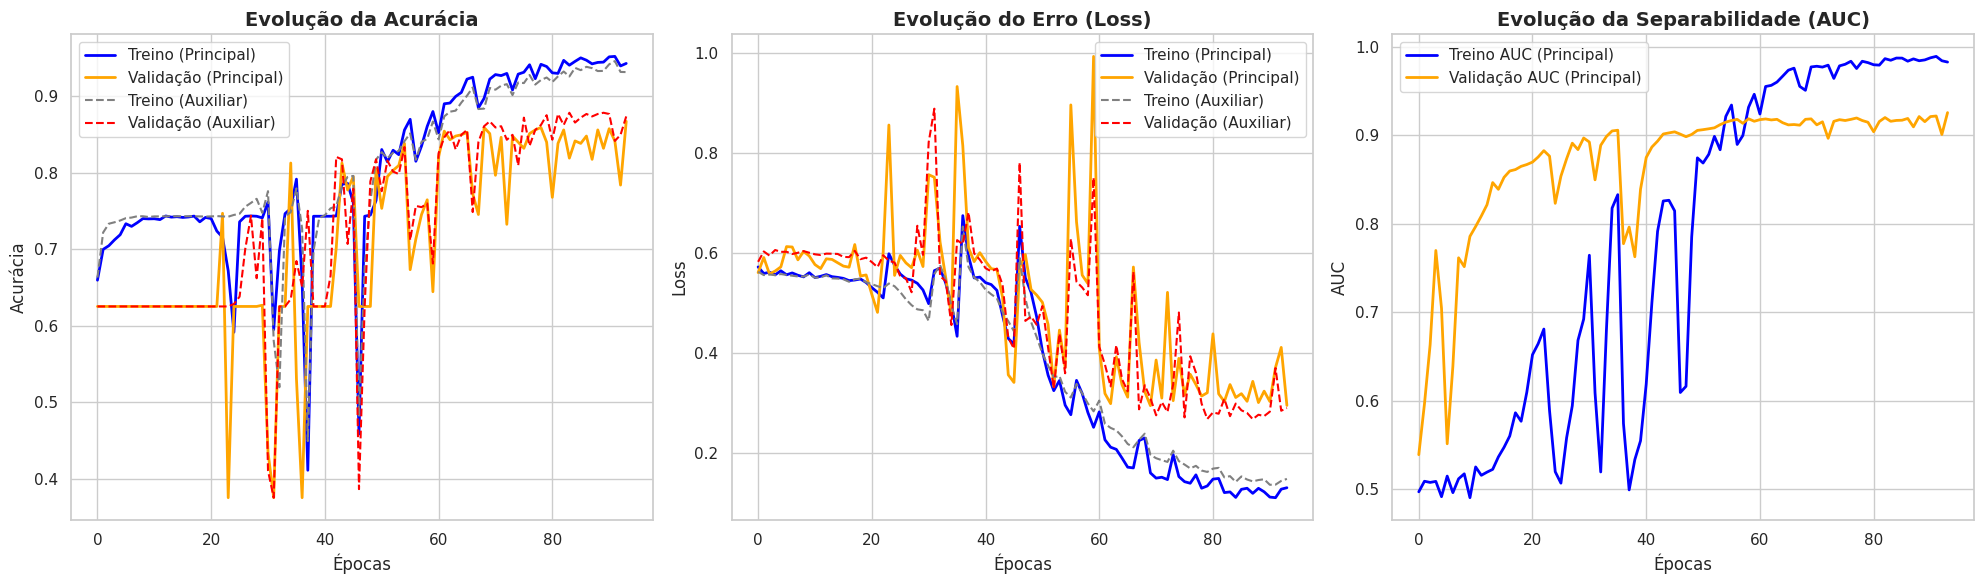

In [17]:
# Configura o estilo para deixar os gráficos com cara de artigo científico
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- 1. Gráfico de Acurácia (Principal vs Auxiliar) ---
axes[0].plot(history.history['output_accuracy'], label='Treino (Principal)', color='blue', linewidth=2)
axes[0].plot(history.history['val_output_accuracy'], label='Validação (Principal)', color='orange', linewidth=2)
axes[0].plot(history.history['auxilliary_output_1_accuracy'], label='Treino (Auxiliar)', color='gray', linestyle='--')
axes[0].plot(history.history['val_auxilliary_output_1_accuracy'], label='Validação (Auxiliar)', color='red', linestyle='--')
axes[0].set_title('Evolução da Acurácia', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Épocas', fontsize=12)
axes[0].set_ylabel('Acurácia', fontsize=12)
axes[0].legend()

# --- 2. Gráfico de Loss (Principal vs Auxiliar) ---
axes[1].plot(history.history['output_loss'], label='Treino (Principal)', color='blue', linewidth=2)
axes[1].plot(history.history['val_output_loss'], label='Validação (Principal)', color='orange', linewidth=2)
axes[1].plot(history.history['auxilliary_output_1_loss'], label='Treino (Auxiliar)', color='gray', linestyle='--')
axes[1].plot(history.history['val_auxilliary_output_1_loss'], label='Validação (Auxiliar)', color='red', linestyle='--')
axes[1].set_title('Evolução do Erro (Loss)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Épocas', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend()

# --- 3. Gráfico de AUC (Apenas Principal, foco na métrica final) ---
# Se a sua saída auxiliar também tiver AUC, você pode adicionar aqui, 
# mas geralmente avaliamos o AUC apenas na saída final do modelo.
axes[2].plot(history.history['output_auc'], label='Treino AUC (Principal)', color='blue', linewidth=2)
axes[2].plot(history.history['val_output_auc'], label='Validação AUC (Principal)', color='orange', linewidth=2)
axes[2].set_title('Evolução da Separabilidade (AUC)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Épocas', fontsize=12)
axes[2].set_ylabel('AUC', fontsize=12)
axes[2].legend()

plt.tight_layout()
plt.show()

## Avaliação: A Matriz de Confusão

A **matriz de confusão** é a ferramenta mais completa para avaliar classificadores binários. Ao contrário da acurácia — que trata todos os erros como iguais — ela detalha os 4 tipos de resultado possíveis para cada par (real vs predito):

| | Predito: NORMAL | Predito: PNEUMONIA |
| :--- | :---: | :---: |
| **Real: NORMAL** | **TN** | **FP** |
| **Real: PNEUMONIA** | **FN** | **TP** |

| Sigla | Nome | Significado neste problema |
| :--- | :--- | :--- |
| **TN** | True Negative (Verdadeiro Negativo) | Paciente saudável corretamente identificado como NORMAL ✅ |
| **FP** | False Positive (Falso Positivo) | Paciente saudável erroneamente classificado como PNEUMONIA ❌ — gera ansiedade e re-exame desnecessário |
| **FN** | False Negative (Falso Negativo) | Paciente doente erroneamente liberado como NORMAL ❌ — **o erro mais perigoso clinicamente** |
| **TP** | True Positive (Verdadeiro Positivo) | Paciente doente corretamente identificado como PNEUMONIA ✅ |

### Por que a Matriz de Confusão é mais informativa que a acurácia?

Um modelo "preguiçoso" que sempre prevê PNEUMONIA atingiria ~74% de acurácia neste dataset (pois ~74% das imagens de teste são de Pneumonia). O número parece bom, mas o modelo teria TN=0 e seria clinicamente inútil. A Matriz de Confusão expõe esse tipo de comportamento imediatamente.

No contexto médico de triagem, o objetivo absoluto é **minimizar Falsos Negativos (FN)** (não deixar pacientes doentes passarem despercebidos) mesmo que isso gere uma taxa maior de Falsos Positivos (FP) (pacientes saudáveis encaminhados para exames adicionais). Esse comportamento médico ideal ficou evidente na evolução e no ajuste de hiperparâmetros dos nossos Testes 07, 08, 09 e 10.

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step

=== Primeiros 5 exemplos do conjunto de teste ===
  [0] Predito: PNEUMONIA  | Real: NORMAL     | Prob: 0.8514 ❌
  [1] Predito: PNEUMONIA  | Real: NORMAL     | Prob: 0.8479 ❌
  [2] Predito: NORMAL     | Real: NORMAL     | Prob: 0.0454 ✅
  [3] Predito: PNEUMONIA  | Real: NORMAL     | Prob: 0.9283 ❌
  [4] Predito: NORMAL     | Real: NORMAL     | Prob: 0.1119 ✅

Acurácia no conjunto de teste: 0.8590 (85.90%)


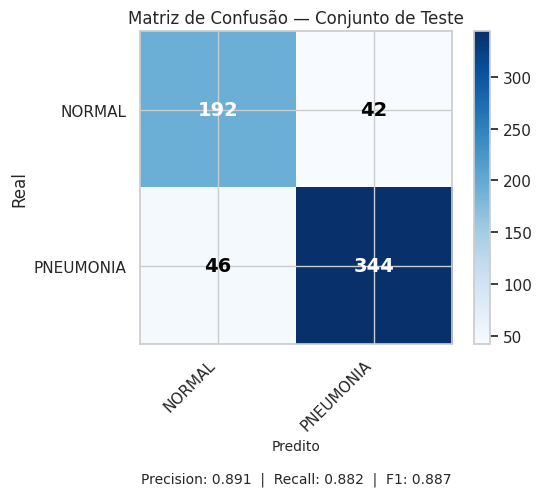


  TN (NORMAL→NORMAL):       192
  FP (NORMAL→PNEUMONIA):    42  ← viés do modelo
  FN (PNEUMONIA→NORMAL):    46
  TP (PNEUMONIA→PNEUMONIA): 344


In [14]:
# --- Predições ---
predictions = model.predict(X_test)
main_predictions, aux1_predictions = predictions

predicted_classes = (main_predictions >= 0.5).astype(int).flatten()
true_classes      = y_test.flatten().astype(int)

# --- Top-5 e Acurácia (bloco original mantido) ---
print('\n=== Primeiros 5 exemplos do conjunto de teste ===')
for i in range(5):
    prob   = main_predictions[i][0]
    pred   = class_names[predicted_classes[i]]
    true   = class_names[true_classes[i]]
    status = '✅' if predicted_classes[i] == true_classes[i] else '❌'
    print(f'  [{i}] Predito: {pred:10s} | Real: {true:10s} | Prob: {prob:.4f} {status}')

acc = np.mean(predicted_classes == true_classes)
print(f'\nAcurácia no conjunto de teste: {acc:.4f} ({acc*100:.2f}%)')

# --- Matriz de Confusão (puro NumPy + Matplotlib, sem sklearn) ---
def plot_confusion_matrix(y_true, y_pred, class_names):
    n = len(class_names)
    cm = np.zeros((n, n), dtype=int)
    for true, pred in zip(y_true, y_pred):
        cm[true][pred] += 1

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(n),
        yticks=np.arange(n),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel='Predito',
        ylabel='Real',
        title='Matriz de Confusão — Conjunto de Teste'
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    thresh = cm.max() / 2
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{cm[i, j]}',
                    ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black',
                    fontsize=14, fontweight='bold')

    # Anotações de métricas-chave
    tn, fp = cm[0][0], cm[0][1]   # NORMAL real → predito NORMAL / PNEUMONIA
    fn, tp = cm[1][0], cm[1][1]   # PNEUMONIA real → predito NORMAL / PNEUMONIA
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    ax.set_xlabel(
        f'Predito\n\nPrecision: {precision:.3f}  |  Recall: {recall:.3f}  |  F1: {f1:.3f}',
        fontsize=10
    )

    plt.tight_layout()
    plt.show()
    print(f'\n  TN (NORMAL→NORMAL):       {tn}')
    print(f'  FP (NORMAL→PNEUMONIA):    {fp}  ← viés do modelo')
    print(f'  FN (PNEUMONIA→NORMAL):    {fn}')
    print(f'  TP (PNEUMONIA→PNEUMONIA): {tp}')

plot_confusion_matrix(true_classes, predicted_classes, class_names)

## Salvamento do Modelo

In [15]:
# Salva o modelo treinado
model.save('inception_v1_binary_chestxray.h5')
print('Modelo salvo: inception_v1_binary_chestxray.h5')

Modelo salvo: inception_v1_binary_chestxray.h5


## Referência das Imagens Externas de Teste (Inferência em Produção)

### (Domain Shift)

Para validar a verdadeira robustez do modelo, esse teste avalia como a CNN se comporta diante de um **Domain Shift** (deslocamento de domínio), como diferentes calibragens de raio-x, recortes de imagem variados e resoluções diversas.

Para garantir que o modelo não está viciado apenas no conjunto de dados original, utilizamos 7 radiografias reais provenientes de fontes médicas públicas para o teste final de inferência. Abaixo estão as fontes e o diagnóstico verificado de cada imagem:

| # | Diagnóstico Real | Fonte / Banco de Imagens | Descrição Clínica |
|---|---|---|---|
| 1 | **NORMAL** | [Radiopaedia.org](https://radiopaedia.org/) | Radiografia de tórax com pulmões limpos e anatomia cardíaca padrão. |
| 2 | **PNEUMONIA** | [Radiopaedia.org](https://radiopaedia.org/) | Infecção pulmonar visível com consolidação. |
| 3 | **NORMAL** | [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Normal_posteroanterior_(PA)_chest_radiograph_(X-ray).jpg) | Raio-x posteroanterior (PA) padrão de um paciente saudável. |
| 4 | **PNEUMONIA** | [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Pneumonia_x-ray.jpg) | Radiografia frontal demonstrando opacidade típica de infecção. |
| 5 | **PNEUMONIA** | [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Lobar_pneumonia,_acute_(3785988179).jpg) | Caso agudo de pneumonia lobar, com o lóbulo pulmonar claramente afetado. (Domain Shift)|
| 6 | **NORMAL** | [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Rx_t%C3%B3rax_normal_F.JPG) | Radiografia torácica normal de uma paciente do sexo feminino. |
| 7 | **PNEUMONIA** | [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:X-ray_of_bronchopneumonia.png) | Broncopneumonia multifocal bilateral (infecção espalhada em ambos os pulmões). |

> **Nota:** As imagens da Wikipédia/Wikimedia podem sofrer bloqueio de *rate-limit* (Erro HTTP 429). Foi adicionado um atraso (`time.sleep`) no script para simular requisições humanas e contornar a limitação dos servidores.

In [18]:
import time

# Lista de tuplas contendo: (URL, Classe Real da Imagem)
image_data = [
    ('https://prod-images-static.radiopaedia.org/images/220869/76052f7902246ff862f52f5d3cd9cd_big_gallery.jpg', 'NORMAL'),
    ('https://prod-images-static.radiopaedia.org/images/554213/27e6e725de1f349479fd214944aaf0d32523ec38f111107b6f347a3530e4b4ff_big_gallery.jpeg', 'PNEUMONIA'),
    ('https://en.wikipedia.org/wiki/Special:FilePath/Normal_posteroanterior_(PA)_chest_radiograph_(X-ray).jpg', 'NORMAL'),
    ('https://en.wikipedia.org/wiki/Special:FilePath/Pneumonia_x-ray.jpg', 'PNEUMONIA'),
    ('https://en.wikipedia.org/wiki/Special:FilePath/Lobar_pneumonia,_acute_(3785988179).jpg', 'PNEUMONIA'),
    ('https://en.wikipedia.org/wiki/Special:FilePath/Rx_t%C3%B3rax_normal_F.JPG', 'NORMAL'),
    ('https://en.wikipedia.org/wiki/Special:FilePath/X-ray_of_bronchopneumonia.png', 'PNEUMONIA')
]

def load_and_preprocess_image(url):
    try:
        # Header mais robusto simulando um Google Chrome no Windows
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
        }
        response = requests.get(url, headers=headers)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content))
        img = img.resize((32, 32))
        img_array = image.img_to_array(img)
        
        # Garante 3 canais (grayscale → RGB)
        if img_array.shape[2] == 1:
            img_array = np.repeat(img_array, 3, axis=2)
        elif img_array.shape[2] == 4: # RGBA → RGB
            img_array = img_array[:, :, :3]
        
        img_array = img_array / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        return img_array
    except Exception as e:
        print(f'Erro ao carregar imagem de {url}: {e}')
        return None

# Loop iterando sobre as URLs e as classes reais (labels)
for url, true_label in image_data:
    img_array = load_and_preprocess_image(url)
    if img_array is not None:
        predictions = model.predict(img_array, verbose=0)
        main_pred = predictions[0]
        prob = main_pred[0][0]
        
        # 🔧 Usando o threshold de 0.5 (ou 0.65 se você ajustou)
        predicted_class = class_names[int(prob >= 0.5)]
        
        # Verifica se acertou
        status = '✅' if predicted_class == true_label else '❌'
        
        print(f'URL: ...{url[-40:]}')
        print(f'  Real: {true_label:10s} | Predito: {predicted_class:10s} | Prob PNEUMONIA: {prob:.4f} {status}\n')
    else:
        print(f'Pulando imagem de {url} devido a erro de carregamento.\n')
    
    # Delay de 10 segundos para evitar o Erro 429 da Wikipedia
    time.sleep(10)

URL: ...7902246ff862f52f5d3cd9cd_big_gallery.jpg
  Real: NORMAL     | Predito: NORMAL     | Prob PNEUMONIA: 0.0458 ✅

URL: ...111107b6f347a3530e4b4ff_big_gallery.jpeg
  Real: PNEUMONIA  | Predito: PNEUMONIA  | Prob PNEUMONIA: 0.9829 ✅

URL: ...terior_(PA)_chest_radiograph_(X-ray).jpg
  Real: NORMAL     | Predito: NORMAL     | Prob PNEUMONIA: 0.3074 ✅

URL: ...iki/Special:FilePath/Pneumonia_x-ray.jpg
  Real: PNEUMONIA  | Predito: NORMAL     | Prob PNEUMONIA: 0.0290 ❌

URL: .../Lobar_pneumonia,_acute_(3785988179).jpg
  Real: PNEUMONIA  | Predito: PNEUMONIA  | Prob PNEUMONIA: 0.9923 ✅

URL: ...cial:FilePath/Rx_t%C3%B3rax_normal_F.JPG
  Real: NORMAL     | Predito: NORMAL     | Prob PNEUMONIA: 0.0657 ✅

URL: ...l:FilePath/X-ray_of_bronchopneumonia.png
  Real: PNEUMONIA  | Predito: NORMAL     | Prob PNEUMONIA: 0.2765 ❌



### Histórico de Experimentos CNN - Raio-X Pneumonia

| Teste | Épocas | Acurácia Treino | Acurácia Validação | Acurácia Teste | Loss Validação (Output) | Taxa de Aprendizado | Observações (Top 5 Predições) |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **01** Maioria do código base só diminuição de épocas | 20 | 90.31% | 79.49% | 79.49% | 0.6572 | 0.0085 | Errou 4/5 (falso positivo para Pneumonia). Modelo inclinado a prever a classe majoritária. |
| **02** Aumento de épocas | 100 | 97.32% | 74.68% | 74.68% | 1.1724 | 0.0044 | Piora nos resultados de teste e validação. Loss de validação quase dobrou — overfitting claro. Errou 4/5. |
| **03** Diminuição de épocas e adição de sample_weights | 15 | 78.21% | 63.94% | 63.94% | 0.8766 | 0.0088 | sample_weight ainda não corrigiu o viés: errou 5/5 no top-5, prevendo PNEUMONIA para todos os casos NORMAL com alta confiança. Queda expressiva indica colapso na última época. |
| **04** Adição data augmentation e L2 | 15 | 58.57% | 37.66% | 37.66% | 0.7058 | 0.0088 | **Underfitting severo** após adição de Augmentation + L2. Modelo não teve tempo de aprender e previu "NORMAL" para todas as imagens (probs travadas em ~0.48). Acertou 5/5 apenas por coincidência. |
| **05** Compilação completa (Métricas + Early Stop) | 15 | 48.26% | 55.61% | 55.61% | 0.6931 | 0.0088 | AUC promissor (0.77), indicando que o modelo está aprendendo a separar as classes. Porém, CM revela viés invertido (muitos Falsos Negativos: 271) devido ao sample_weight. |
| **06** Teste aumentando as épocas | 100 -> 29 (Stop) | 58.99% | 77.08% | 77.08% | 0.5835 | 0.0082 | **Modelo equilibrado**. Early Stopping interrompeu na época 29 e restaurou a 24. Acurácia sólida, AUC excelente de 0.87. As probabilidades distanciaram-se de 0.5. |
| **07** Novo teste (50 Épocas + URLs externas) | 50 -> 22 (Stop) | 61.39% | 73.24% | 73.24% | 0.6101 | 0.0088 | **Alta Sensibilidade Médica**. Parou na época 22. O modelo priorizou minimizar Falsos Negativos (caíram para 11), gerando Falsos Positivos (156). Comportamento excelente para triagem. |
| **08** Repetição do T07 | 50 -> 30 (Stop) | 62.26% | 70.99% | 70.99% | 0.4992 | 0.0082 | **Confirmação do padrão de Triagem**. Parou na época 30. AUC excelente (0.869). O modelo mantém a segurança de não deixar doentes passarem (apenas 9 FN). |
| **09** Suavização de Sample Weights (x0.65) | 50 -> 49 (Stop) | 82.44% | 83.49% | 83.49% | 0.3574 | 0.0069 | **Modelo Otimizado**. Balanceamento na Matriz de Confusão. FP despencaram para 37. Acurácia bateu recorde (83.49%) e AUC de excelência (0.9224). |
| **10** Redução da Punição L2 (0.0005) + 500 Épocas | 500 -> 96 (Stop) | 88.75% | 84.13% | 84.13% | 0.3187 | 0.0046 | **Acurácia Recorde e Loss Quase na Meta**. Menos L2 permitiu à rede aprender até a época 96. FN caíram para 41 (modelo mais seguro clinicamente) mantendo excelente controle de FP (58). Acurácia atingiu o pico do projeto (84.13%) e o Loss de predição bateu na trave dos 30% (0.318). |